In [1]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
from matplotlib import ticker
%matplotlib inline
DATADIR = "./"
plt.rcParams['figure.figsize'] = [8, 5]
FONT_TITLE = 18
FONT_AXES = 18
FONT_TICKS = 16
FONT_LEGEND = 14

plt.rc('axes', titlesize=FONT_AXES)     # fontsize of the axes title
plt.rc('axes', labelsize=FONT_AXES)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=FONT_TICKS)    # fontsize of the tick labels
plt.rc('ytick', labelsize=FONT_TICKS)    # fontsize of the tick labels
plt.rc('legend', fontsize=FONT_LEGEND)    # legend fontsize
plt.rc('figure', titlesize=FONT_TITLE)  # fontsize of the figure title


In [22]:
def graph500_plotter(df, system_string, scale, edgefactors, partitions):
    for metric, label, scaling_factor in [
        ("total_runtime[s]", "Time in seconds", 1),
    ]:
        fig, axes = plt.subplots(len(edgefactors), len(partitions), figsize=(6 * len(partitions), 4 * len(edgefactors)), sharey=True)
        fig.suptitle(f'{system_string} -- Scale: {scale}', fontsize=FONT_AXES)

        if len(partitions) == 1 and len(edgefactors) == 1:
            axes = [axes]

        for axs, edgefactor in zip(axes, edgefactors):
            for ax, partition in zip(axs, partitions):
                part_df = df[(df.scale == scale) & (df.partition == partition) & (df.edgefactor == edgefactor)]
                pivoted_df = part_df.pivot_table(
                    columns=["taskspernode", "threadspertask"],
                    index=["nodes"],
                    values=metric
                )
                pivoted_df.div(scaling_factor).plot(
                    ax=ax,
                    grid=True,
                    xlabel="# Nodes",
                    ylabel=f'EF: {edgefactor} - {label}',
                    linewidth=1.5,
                    marker='.',
                    markersize=10,
                    title=f"{label} (partition={partition})"
                )
                ax.set_xscale("log", base=2)
                ax.set_yscale("log", base=2)
                # ax.set_xticks(ticks=pivoted_df.index)
                # ax.set_xticklabels(labels=pivoted_df.index.values)
                ax.set_xticks(ticks=[1,2,4,8])
                ax.set_xticklabels(labels=['1','2','4','8'])
                n = 32
                min_r = pivoted_df.div(scaling_factor).min().min()
                max_r = pivoted_df.div(scaling_factor).max().max()
                y_ticks = [2**j for j in range(-5, n+1) if 2**(j+1) > min_r and 2**(j-1) < max_r]
                ax.set_yticks(ticks=y_ticks)
                ax.set_yticklabels(labels=y_ticks)
                ax.tick_params(which="major", width=1.00, length=7)
                ax.tick_params(which="minor", width=0.25, length=3)
                ax.yaxis.set_major_locator(ticker.LogLocator(base=2.0, numticks=10))
        plt.tight_layout()

    # BFS metrics plot (mean and mean_cut)
    for metric_pair, label in [
        (("bfs_harmonic_mean_teps", "bfs_harmonic_mean_cut_teps"), "BFS TTEPS"),
        (("sssp_harmonic_mean_teps", "sssp_harmonic_mean_cut_teps"), "SSSP TTEPS"),
    ]:
        fig, axes = plt.subplots(len(edgefactors), len(partitions), figsize=(8 * len(partitions), 6 * len(edgefactors)), sharey=True)
        fig.suptitle(f'{system_string} -- Scale: {scale} -- {label}', fontsize=FONT_AXES)
        if len(partitions) == 1 and len(edgefactors) == 1:
            axes = [axes]
        for axs, edgefactor in zip(axes, edgefactors):
            for ax, partition in zip(axs, partitions):
                part_df = df[(df.scale == scale) & (df.partition == partition) & (df.edgefactor == edgefactor)]
                # & ((df[metric_pair[0]] > 0) | (df[metric_pair[1]] > 0))]
                for metric, sublabel in zip(metric_pair, ["mean", "mean_cut"]):
                    if sublabel == "mean_cut":
                        part_df = part_df[part_df['bfs_harmonic_mean_cut_teps'] > 0]
                    pivoted_df = part_df.pivot_table(
                        columns=["taskspernode", "threadspertask"],
                        index=["nodes"],
                        values=metric
                    )
                    pivoted_df.div(1e6).plot(
                        ax=ax,
                        grid=True,
                        xlabel="# Nodes",
                        ylabel=f'EF: {edgefactor} - {label}',
                        linewidth=1.5,
                        marker='.',
                        markersize=10,
                        title=f"{label} (partition={partition})",
                        legend=True if sublabel == "mean_cut" else False,
                        label=sublabel
                    )
                    ax.set_xscale("log", base=2)
                    ax.set_yscale("log", base=2)
                    ax.set_xticks(ticks=[1,2,4,8])
                    ax.set_xticklabels(labels=['1','2','4','8'])
                    # ax.set_xticks(ticks=pivoted_df.index)
                    # ax.set_xticklabels(labels=pivoted_df.index.values)
                    # n = 32
                    # min_r = part_df[list(metric_pair)].div(1e9).min().min()
                    # max_r = part_df[list(metric_pair)].div(1e9).max().max()
                    # y_ticks = [2**j for j in range(-5, n+1) if 2**(j+1) > min_r and 2**(j-1) < max_r]
                    # ax.set_yticks(ticks=y_ticks)
                    # ax.set_yticklabels(labels=y_ticks)
                    # ax.tick_params(which="major", width=1.00, length=7)
                    # ax.tick_params(which="minor", width=0.25, length=3)
                    # ax.yaxis.set_major_locator(ticker.LogLocator(base=2.0, numticks=10))
                    ax.legend(["TTEPS", " TTEPS (cut)"])
        plt.tight_layout()

# Graph500 on HAICGU

In [16]:
df = pd.read_csv(DATADIR+'graph500_mix.csv')
scales = df["scale"].unique()
partitions = df["partition"].unique()
edgefactors = df["edgefactor"].unique()

# print(scales)
# print(df[df['nodes']>4])
# print(df[(df['scale']==14) & (df['edgefactor']==32)][['partition', 'nodes', 'scale', 'edgefactor', 'total_runtime[s]']])

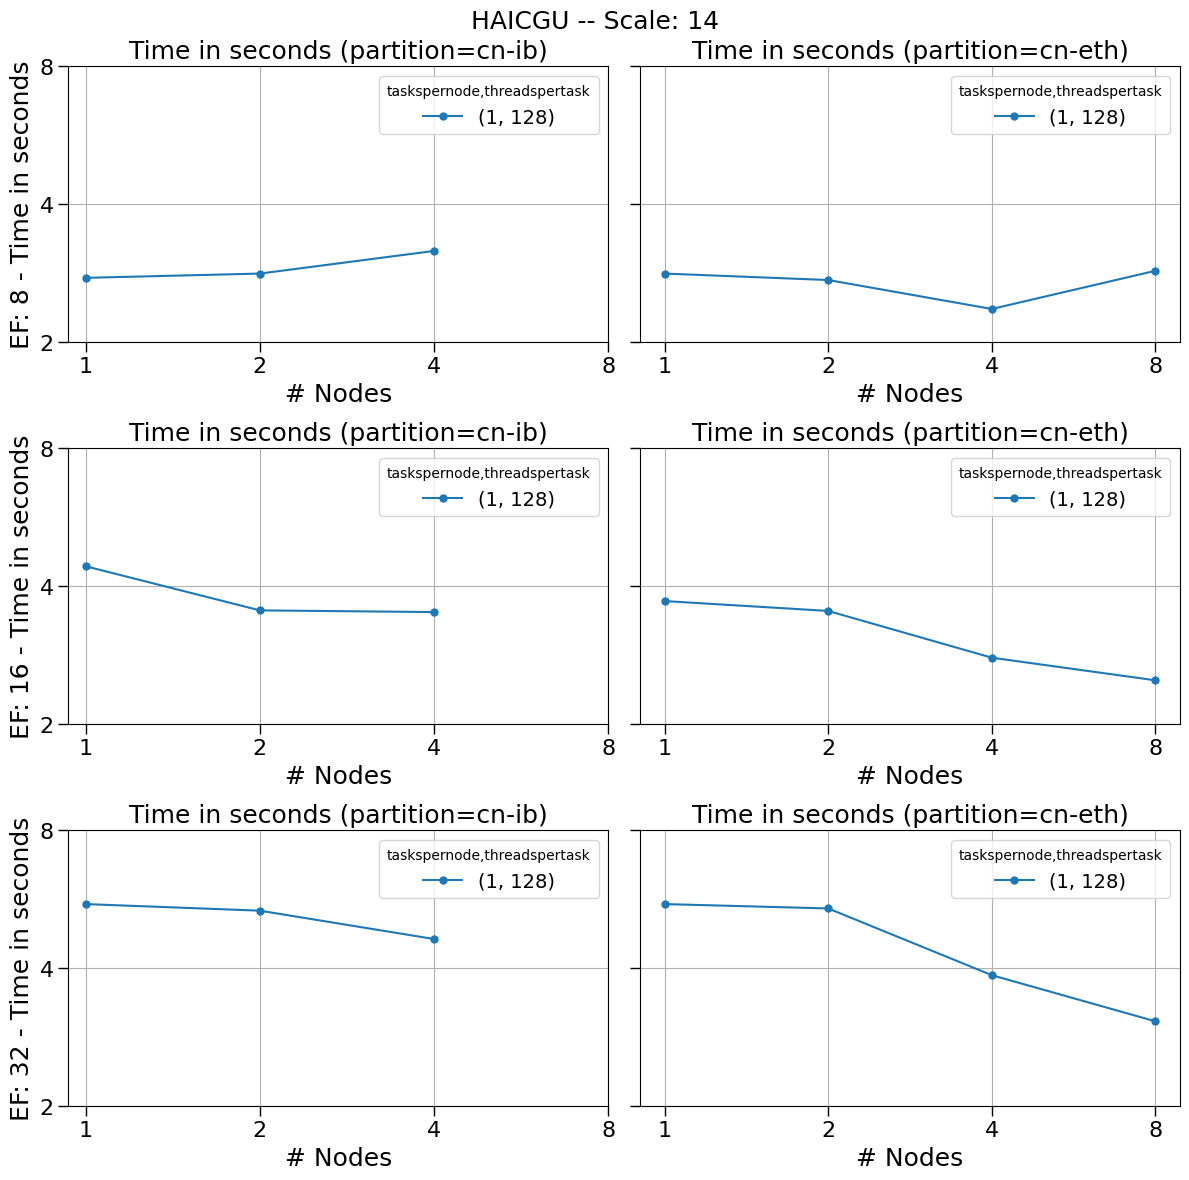

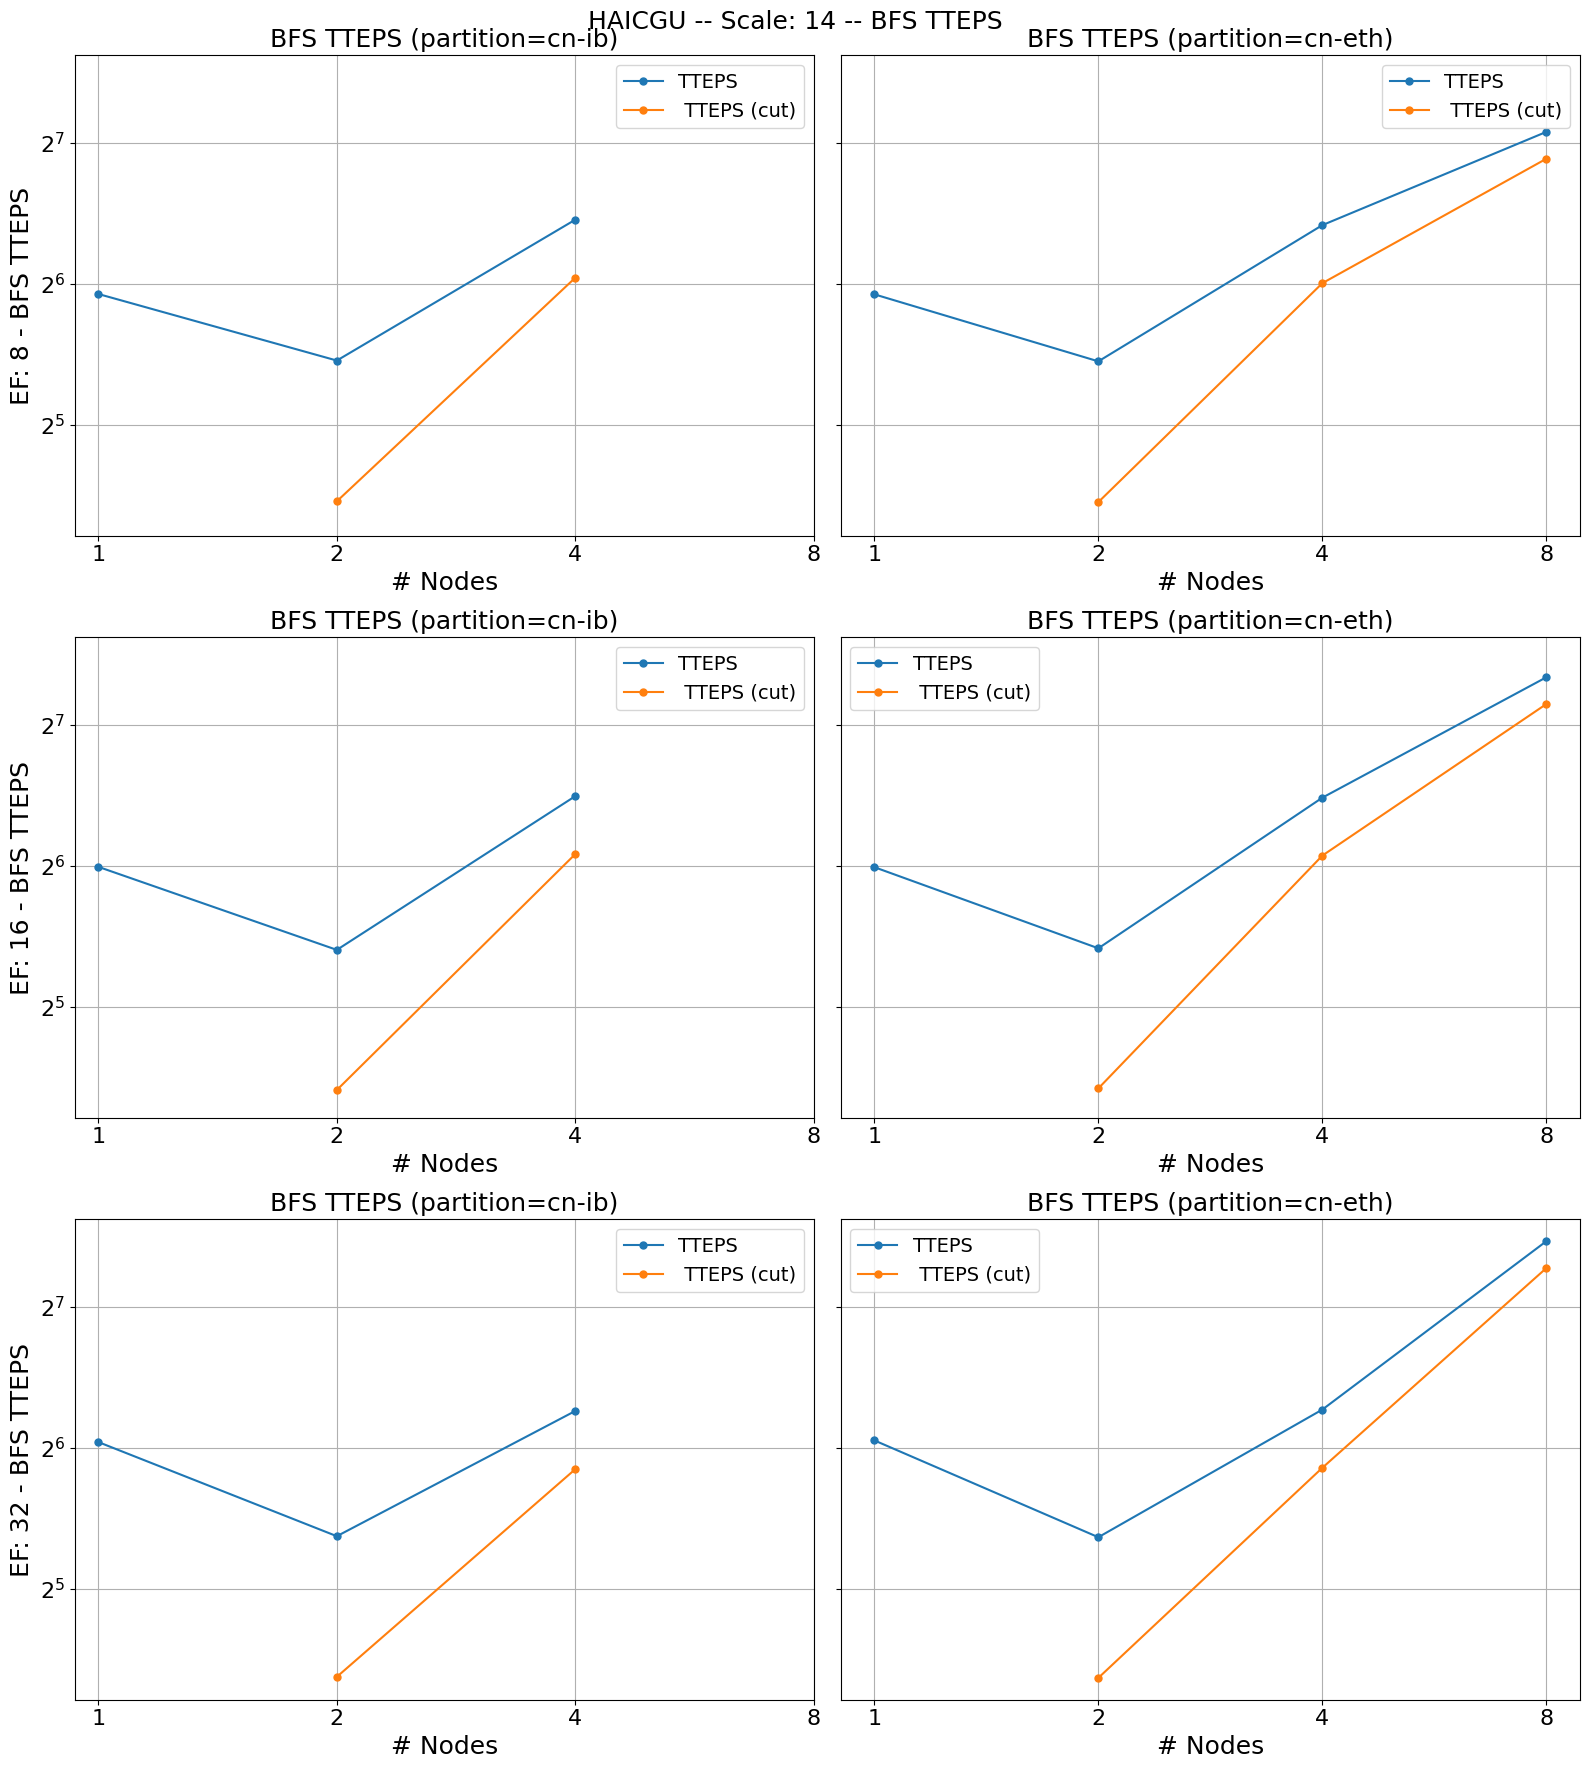

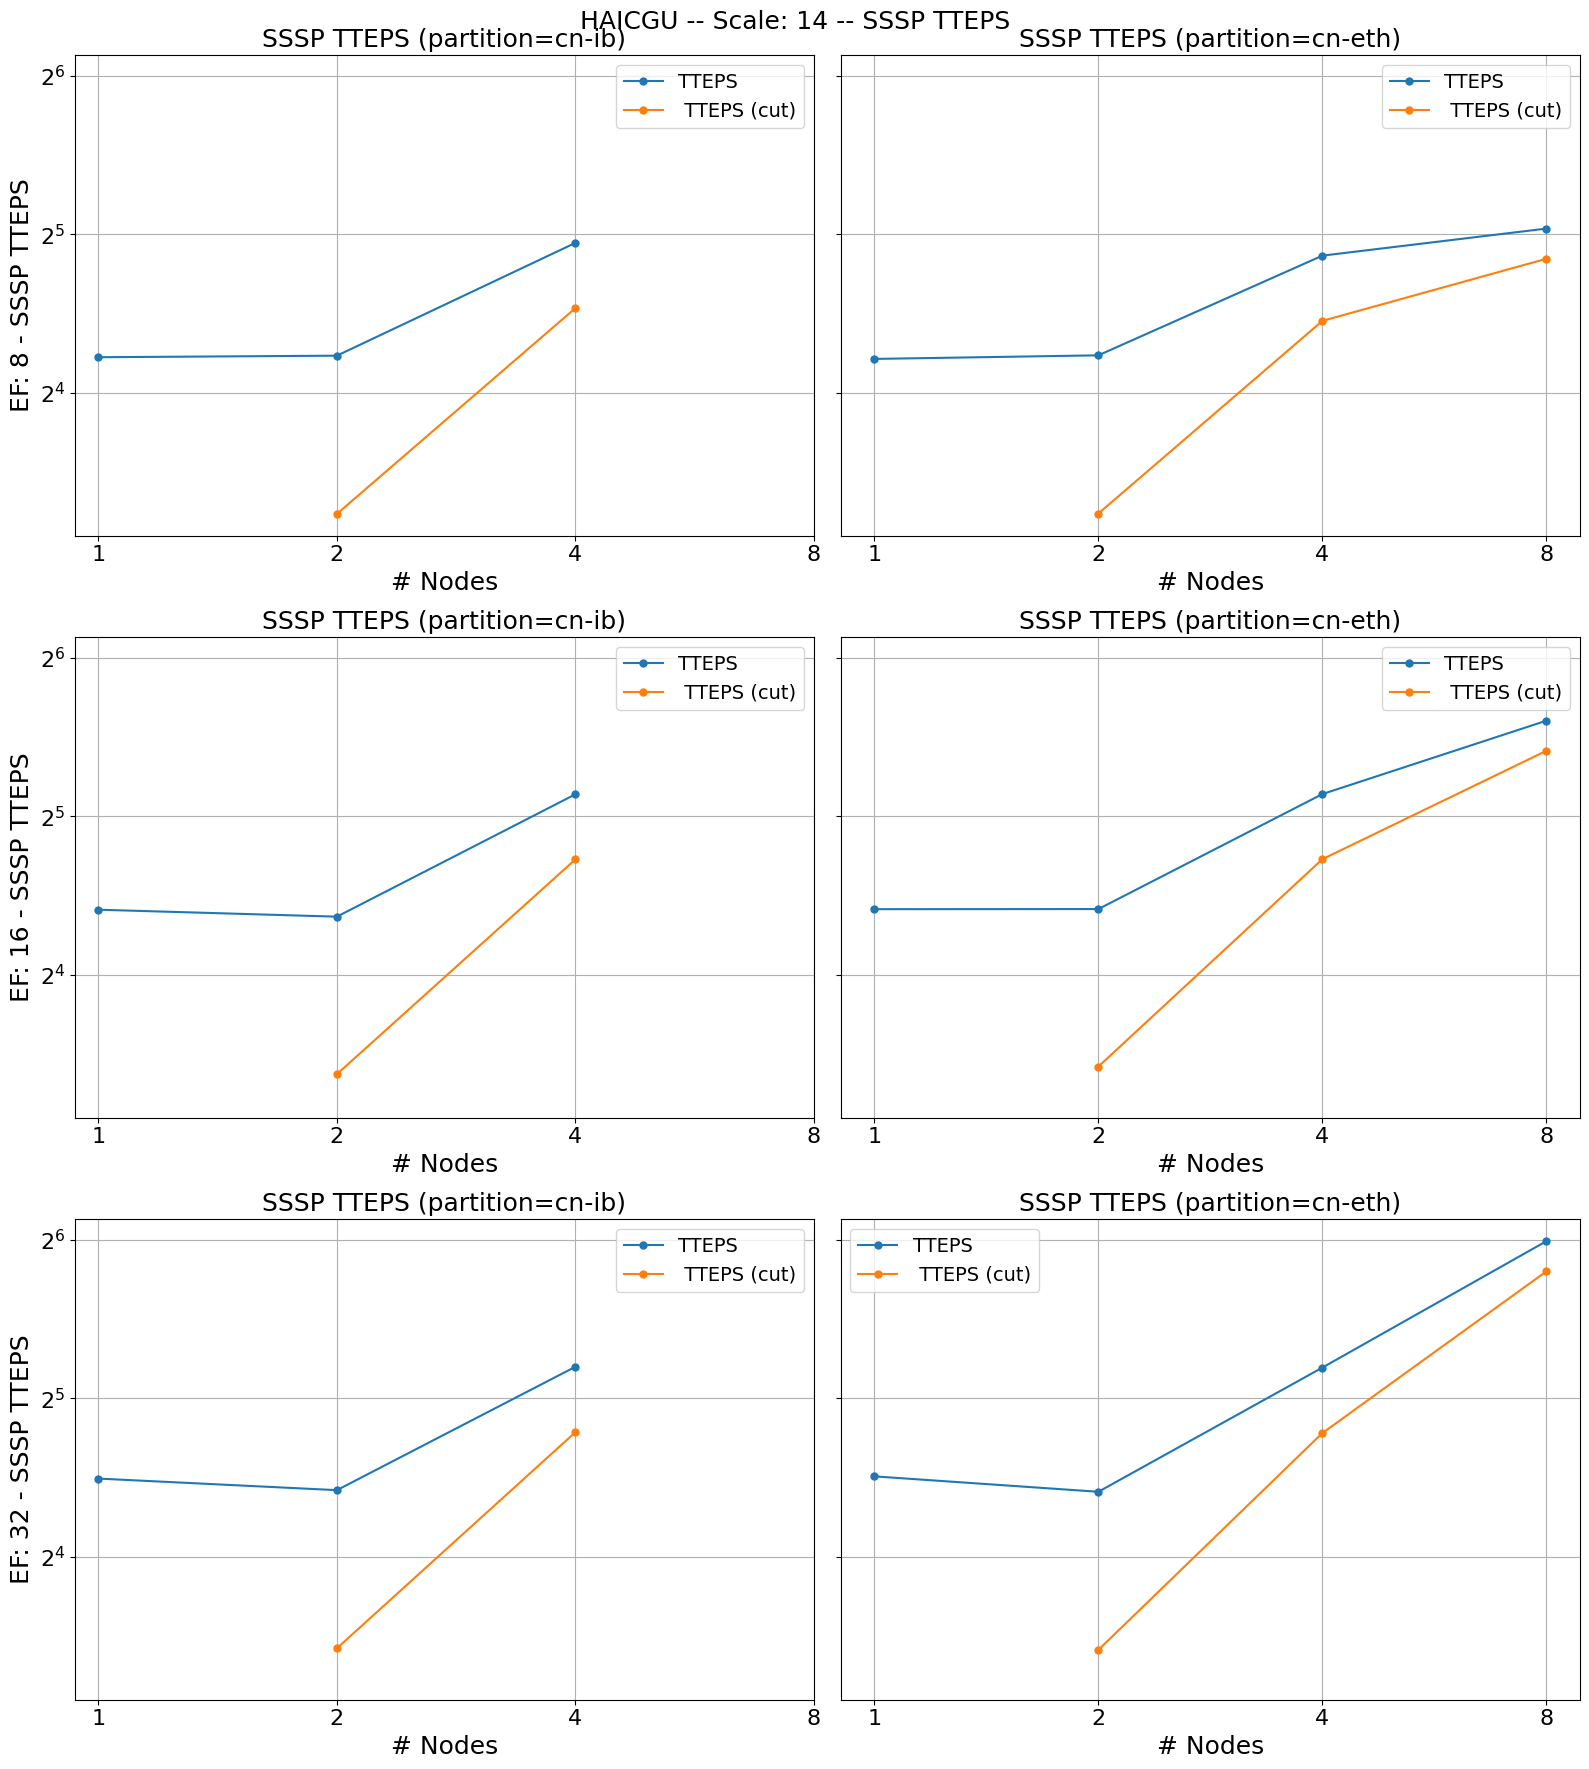

In [23]:
for scale in [14]: #scales:
    # print(f"{'='*100} SCALE {scale} {'='*100}")
    graph500_plotter(df, "HAICGU", scale, edgefactors, partitions)